In [ ]:
!pip install shap
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgbimport
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from boruta import BorutaPy



# Load the data
df = pd.read_csv(
    'large_fires_data_v2_ndfb_kd_co.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'ndfb_kd_co',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

In [ ]:
df.head()

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108,25.791901,343.622009,0.003105,5,0.185952,...,33.974201,0,38.638302,122.428001,-2.81874,5.04358,0.00000,0,18,3.842920
1,188536,68.383883,-97.544667,0.000000,30,-9999.000000,29.983200,0.002183,8,0.079882,...,-9999.000000,0,-9999.000000,-9999.000000,-9999.00000,-9999.00000,306.02301,0,0,-9999.000000
2,142254,63.383883,-94.961333,0.000000,113,35.641201,142.042007,0.002544,3,0.118337,...,25.044300,0,39.882900,120.940002,-5.93237,5.63601,45.00000,0,0,-0.417361
3,170110,66.383883,-123.044667,0.000598,-1,25.696800,156.000000,0.003055,11,-0.051117,...,22.537500,0,18.849199,104.688003,-1.79748,3.65383,14.14210,-9999,0,-0.851500
4,5182,46.133883,-73.544667,0.000017,25,16.150000,94.138496,0.005531,2,0.429686,...,96.328300,0,49.552502,146.054001,10.93730,2.69233,0.00000,32,0,1.050420


In [ ]:
# Replace -9999 with NaN
df.replace(-9999, np.nan, inplace=True)

# Verify if replacement was successful by checking for null values
df.isnull().sum()

,0
point_id,0
lat_dd,0
long_dd,0
ndfb_kd_co,0
Aspect,27
Climatic water deficit,78
Elevation,171
Humidity,98
LULC,103
NDVI,115


In [ ]:
# Drop rows with NaN values
df.dropna(inplace=True)

In [ ]:
replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df['LULC'] = df['LULC'].replace(replace_values_LULC)

In [ ]:
df.head(10)

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub_covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.81874,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass_land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.93237,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop_land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.93730,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree_covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.80500,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop_land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.03230,4.51617,49.497501,17.0,0.0,-0.115882
7,171330,66.467217,-88.378000,0.000000,74.0,34.307098,298.561005,0.002100,Sparse_vegetation,0.064672,...,25.674900,0.0,11.649000,112.188003,-8.41979,4.58282,386.942993,0.0,0.0,-0.419509
8,171040,66.467217,-112.628000,0.000000,205.0,37.411499,481.976990,0.002597,Grass_land,0.126665,...,20.446300,0.0,25.186300,105.348999,-5.18341,4.58974,63.245602,0.0,0.0,0.649869
9,133520,62.300550,-101.711333,0.002948,-1.0,16.660000,266.000000,0.002877,Water_bodies,0.000924,...,27.469000,0.0,38.008800,118.398003,-4.02748,5.48379,18.027800,0.0,0.0,0.135204
11,197830,69.717217,-95.294667,0.000000,236.0,28.190901,16.423500,0.002033,Sparse_vegetation,0.037350,...,13.080000,0.0,5.873330,104.623001,-9.58655,4.75425,411.096008,0.0,0.0,-2.166500
12,165028,65.800550,-88.628000,0.000000,217.0,36.887501,180.914002,0.002130,Sparse_vegetation,0.084306,...,26.125700,1.0,14.422900,114.267998,-7.52132,5.24746,345.398010,0.0,0.0,0.046837


In [ ]:
# Convert necessary columns to categorical
df = df.astype(
    {
        'LULC': 'category'
    }
)

In [ ]:
# # Replace -9999 with NaN
# df.replace(-9999, np.nan, inplace= True)

# # Fill NaN values using forward and Backward fill
# df.fillna(method='ffill', inplace= True)
# df.fillna(method= 'bfill', inplace= True)

In [ ]:
df

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub_covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.818740,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass_land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.932370,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop_land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.937300,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree_covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.805000,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop_land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.032300,4.51617,49.497501,17.0,0.0,-0.115882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,42164,51.800550,-119.294667,0.066987,298.0,40.247398,1234.609985,0.004255,Tree_covered,0.364348,...,82.198196,17.0,38.228600,137.061996,10.527200,1.63274,0.000000,12.0,30.0,-0.320638
9996,83453,55.967217,-102.628000,0.094061,10.0,24.782600,390.493988,0.003904,Shrub_covered,0.360019,...,43.674999,0.0,36.657501,135.151993,4.036580,3.20392,0.000000,0.0,29.0,-0.532250
9997,142023,63.383883,-114.211333,0.066603,45.0,45.147499,304.996002,0.003006,Shrub_covered,0.226289,...,23.678700,0.0,20.494400,115.484001,-0.881827,3.87582,0.000000,0.0,10.0,-0.742617
9998,21169,49.633883,-121.544667,0.151077,21.0,36.743301,1519.750000,0.004994,Tree_covered,0.370431,...,89.547996,10.0,120.483002,135.684006,10.706200,2.26293,0.000000,0.0,0.0,-0.813372


In [ ]:
# Define features and target, X and y
X = df.drop(columns= ['ndfb_kd_co'])
y = df['ndfb_kd_co']

# Split data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Combine features and target back for each dataset
train_data = pd.concat([X_train[['lat_dd', 'long_dd']], y_train], axis=1)
val_data = pd.concat([X_val[['lat_dd', 'long_dd']], y_val], axis=1)
test_data = pd.concat([X_test[['lat_dd', 'long_dd']], y_test], axis=1)

# Save to CSV files
train_data.to_csv('training_data.csv', index=False)
val_data.to_csv('validation_data.csv', index=False)
test_data.to_csv('testing_data.csv', index=False)

In [ ]:
# Define the columns to separate out
index_columns = [

                 'point_id',
                 'lat_dd',
                 'long_dd',
                 'dist_fores',
                 'human_foot',
                 'tree_speci',
                 'pdsi'
]

# Separate index columns for train, validation, and test sets
train_indices = X_train[index_columns]
val_indices = X_val[index_columns]
test_indices = X_test[index_columns]

# Drop these columns from the features
X_train = X_train.drop(columns=index_columns)
X_val = X_val.drop(columns=index_columns)
X_test = X_test.drop(columns=index_columns)


In [ ]:
df.columns

Index(['point_id', 'lat_dd', 'long_dd', 'ndfb_kd_co', 'Aspect',
       'Climatic water deficit', 'Elevation', 'Humidity', 'LULC', 'NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'dist_fores', 'human_foot', 'tree_speci', 'pdsi'],
      dtype='object')

In [ ]:
# Define categorical and numerical columns
categorical_columns = ['LULC']
numerical_columns = ['Climatic water deficit', 'Elevation', 'Humidity','NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',]

# Initialize the OneHotEncoder and StandardScaler
encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

# Fit and transform encoders/scalers on training data
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_columns]),
                               columns=encoder.get_feature_names_out(categorical_columns))
X_val_encoded = pd.DataFrame(encoder.transform(X_val[categorical_columns]),
                             columns=encoder.get_feature_names_out(categorical_columns))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_columns]),
                              columns=encoder.get_feature_names_out(categorical_columns))

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_columns]), columns=numerical_columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[numerical_columns]), columns=numerical_columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis=1)

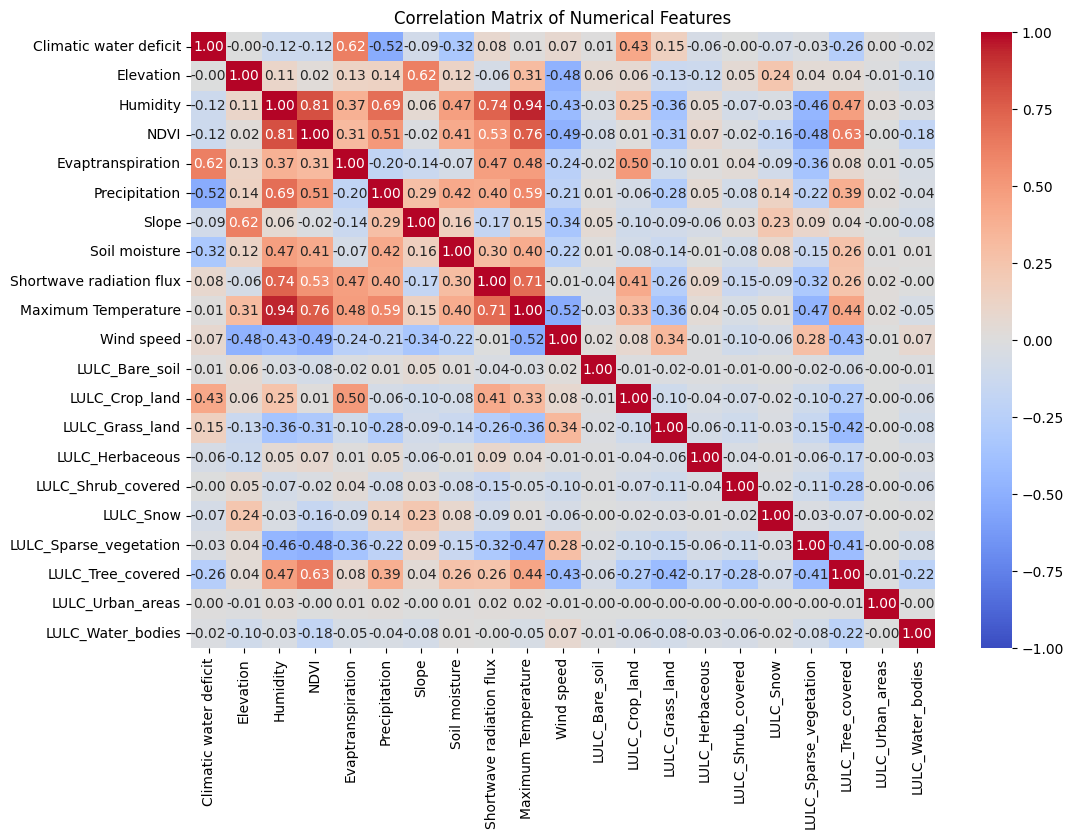

In [ ]:
# Calculate correlation matrix for numerical features
correlation_matrix = X_train_final.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


In [ ]:
# Initialize the RandomForestRegressor
rf = RandomForestRegressor(n_jobs=-1, max_depth=10, random_state=42)

# Fit the RandomForest model to get the feature importances
rf.fit(X_train_final, y_train)

# Initialize Boruta with the RandomForest model
boruta = BorutaPy(estimator=rf, n_estimators=20, max_iter=20, random_state=42, verbose=1)

# Fit Boruta on the preprocessed training data
boruta.fit(X_train_final.values, y_train.values)

# Create a DataFrame for the Boruta results
boruta_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'BorutaDecision': ['Confirmed' if decision else 'Rejected' for decision in boruta.support_]
})

# Initialize the DecisionTreeRegressor (CART)
cart_model = DecisionTreeRegressor(random_state=42)

# Fit the CART model to the training data
cart_model.fit(X_train_final, y_train)

# Extract feature importances
feature_importances = cart_model.feature_importances_

# Create a DataFrame for the CART results
cart_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'RelativeImportance': feature_importances
})

# Combine Boruta and CART results
combined_feature_stats = boruta_feature_stats.merge(cart_feature_stats, on='Variables')

# Save the combined feature stats (both confirmed and rejected) to a CSV file
combined_feature_stats.to_csv('final_feature_stats_with_rejected.csv', index=False)

# Features removed by Boruta
boruta_removed_features = combined_feature_stats[combined_feature_stats['BorutaDecision'] == 'Rejected']['Variables']

# Features with very low importance in CART (threshold < 0.0005)
cart_removed_features = combined_feature_stats[combined_feature_stats['RelativeImportance'] < 0.0005]['Variables']

# Combine the removed features from both methods
removed_features = pd.concat([boruta_removed_features, cart_removed_features]).unique()

# Print removed features
print("Features removed by Boruta or CART:", removed_features)

# Display the final feature stats for those that are kept
final_feature_stats = combined_feature_stats[~combined_feature_stats['Variables'].isin(removed_features)]
print(final_feature_stats)

# Save the final confirmed features to a CSV file for documentation
final_feature_stats.to_csv('final_confirmed_features.csv', index=False)

# Drop the removed features from the datasets automatically
X_train_selected = X_train_final.drop(columns=removed_features, errors='ignore')
X_val_selected = X_val_final.drop(columns=removed_features, errors='ignore')
X_test_selected = X_test_final.drop(columns=removed_features, errors='ignore')

# Save the selected features datasets for reference
X_train_selected.to_csv('X_train_selected.csv', index=False)
X_val_selected.to_csv('X_val_selected.csv', index=False)
X_test_selected.to_csv('X_test_selected.csv', index=False)

# Display summary
print(f"Final selected features saved to: 'X_train_selected.csv', 'X_val_selected.csv', and 'X_test_selected.csv'")
print("Full feature stats (with rejected) saved to 'final_feature_stats_with_rejected.csv'")


Iteration: 1 / 20
Iteration: 2 / 20
Iteration: 3 / 20
Iteration: 4 / 20
Iteration: 5 / 20
Iteration: 6 / 20
Iteration: 7 / 20
Iteration: 8 / 20


BorutaPy finished running.

Iteration: 	9 / 20
Confirmed: 	11
Tentative: 	0
Rejected: 	10
Features removed by Boruta or CART: ['Slope' 'LULC_Bare_soil' 'LULC_Grass_land' 'LULC_Herbaceous'
 'LULC_Shrub_covered' 'LULC_Snow' 'LULC_Sparse_vegetation'
 'LULC_Tree_covered' 'LULC_Urban_areas' 'LULC_Water_bodies']
                   Variables BorutaDecision  RelativeImportance
0     Climatic water deficit      Confirmed            0.125209
1                  Elevation      Confirmed            0.100461
2                   Humidity      Confirmed            0.050542
3                       NDVI      Confirmed            0.022444
4          Evaptranspiration      Confirmed            0.075391
5              Precipitation      Confirmed            0.071349
7              Soil moisture      Confirmed            0.043403
8   Shortwave radiation flux      

In [ ]:
# # Load the CSV file
# file_path = "/content/final_feature_stats_with_rejected.csv"  # Update with your actual file path
# df1 = pd.read_csv(file_path)

# # Sort by 'RelativeImportance' in descending order
# df_sorted = df1.sort_values(by="RelativeImportance", ascending=False)  # Corrected 'ascending'

# # Save the sorted file
# df_sorted.to_csv("final_feature_stats_sorted.csv", index=False)

# # Display sorted DataFrame
# print(df_sorted)

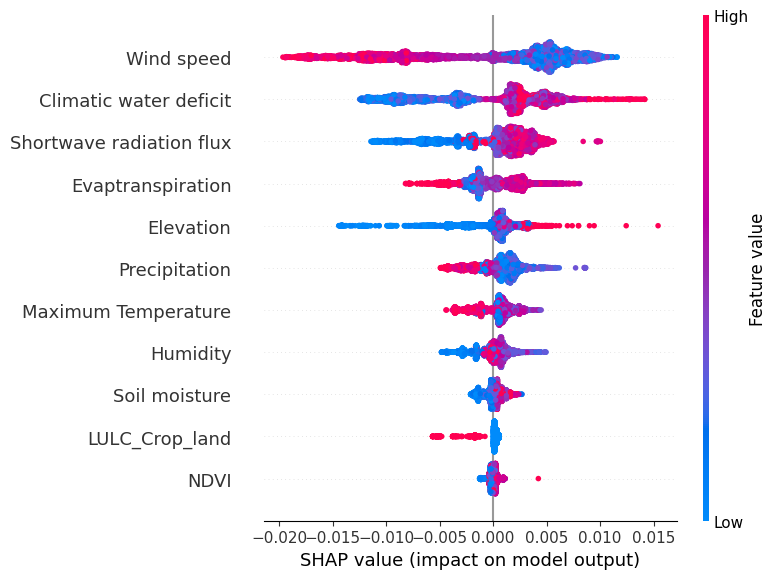

In [ ]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# Convert datasets to XGBoost DMatrix for better performance (optional)
dtrain = xgb.DMatrix(X_train_selected, label=y_train)
dval = xgb.DMatrix(X_val_final, label=y_val)

# Train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.01, random_state=42)
xgb_model.fit(X_train_selected, y_train)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_selected)

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_selected, feature_names=X_train_selected.columns)


In [ ]:
X_train_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_test_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_val_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
# Concatenate the index columns back with the selected features
X_train_final_with_indices = pd.concat([train_indices.reset_index(drop=True), X_train_selected.reset_index(drop=True)], axis=1)
X_val_final_with_indices = pd.concat([val_indices.reset_index(drop=True), X_val_selected.reset_index(drop=True)], axis=1)
X_test_final_with_indices = pd.concat([test_indices.reset_index(drop=True), X_test_selected.reset_index(drop=True)], axis=1)

# Save the updated datasets
X_train_final_with_indices.to_csv('X_train_final_with_indices.csv', index=False)
X_val_final_with_indices.to_csv('X_val_final_with_indices.csv', index=False)
X_test_final_with_indices.to_csv('X_test_final_with_indices.csv', index=False)


In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,0.000000,0.0,18.0,1.957200,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,0.000000,0.0,18.0,-1.410000,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,5.000000,0.0,0.0,0.745807,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,0.000000,0.0,0.0,1.685580,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,5.000000,0.0,0.0,0.666379,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,0.000000,0.0,0.0,-0.009367,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.000000,0.0,17.0,-0.108571,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,60.827599,0.0,0.0,-0.645085,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,0.000000,0.0,0.0,0.518746,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,80.622597,0.0,0.0,0.623167,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,125.000000,13.0,0.0,-0.478534,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.000000,0.0,18.0,1.254830,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,0.000000,1.0,0.0,-3.638680,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.000000,4.0,18.0,-0.660333,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,5.000000,15.0,0.0,1.257830,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,0.000000,0.0,18.0,-0.693437,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,18.027800,0.0,0.0,0.102763,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,0.000000,0.0,0.0,-0.584083,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
# Define the features to drop
features_to_drop = ['dist_fores', 'human_foot', 'pdsi', 'tree_speci']

# Load the datasets
train_file = "X_train_final_with_indices.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features
X_train_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)

# Save the updated datasets
train_updated_file = "X_train_final_with_indices_updated.csv"
val_updated_file = "X_val_final_with_indices_updated.csv"
test_updated_file = "X_test_final_with_indices_updated.csv"

X_train_final_with_indices.to_csv(train_updated_file, index=False)
X_val_final_with_indices.to_csv(val_updated_file, index=False)
X_test_final_with_indices.to_csv(test_updated_file, index=False)



In [ ]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [ ]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


## K-fold spatial cross validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Load dataset
train_file_path = "X_train_final_with_indices.csv"  # Update with your file path
X_train_final_with_indices = pd.read_csv(train_file_path)

# Extract latitude and longitude
coordinates = X_train_final_with_indices[['lat_dd', 'long_dd']]

# Apply K-Means clustering to assign 10 spatial regions
n_splits = 10
kmeans = KMeans(n_clusters=n_splits, random_state=42, n_init=10)
X_train_final_with_indices['spatial_fold'] = kmeans.fit_predict(coordinates)

# Save the corrected spatial folds dataset
X_train_final_with_indices.to_csv("X_train_final_with_corrected_spatial_folds.csv", index=False)

# Display unique fold values
print("Unique spatial folds assigned:", X_train_final_with_indices['spatial_fold'].unique())
print("Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.")


Unique spatial folds assigned: [1 8 2 7 6 3 9 5 4 0]
Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.


In [ ]:
tmp = pd.read_csv('X_train_final_with_corrected_spatial_folds.csv')
tmp

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [ ]:
tmp['spatial_fold'].value_counts(normalize=True)

,proportion
spatial_fold,
6,0.125943
9,0.114992
0,0.111588
5,0.107000
8,0.099600
2,0.098712
1,0.092201
3,0.090573
4,0.088353


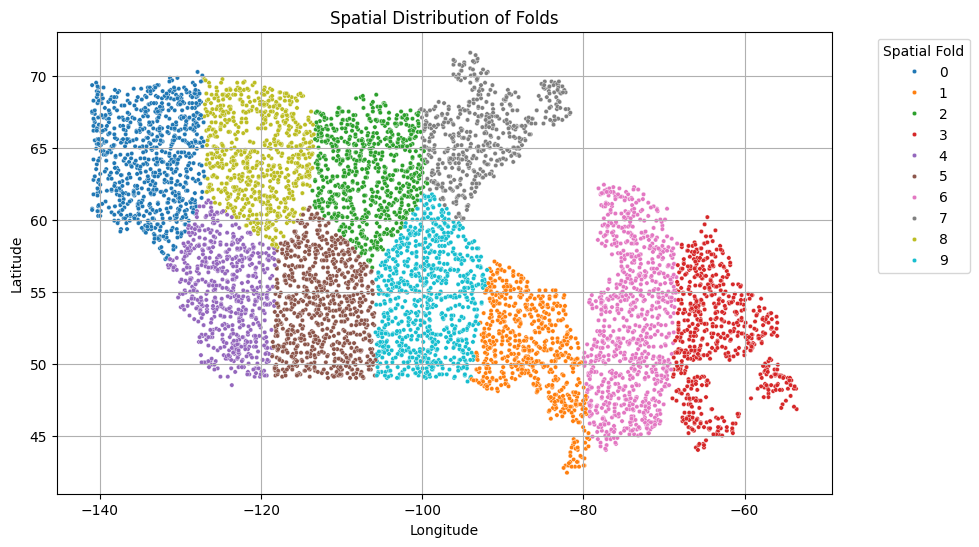

In [ ]:
# Scatter plot of spatial folds
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tmp["long_dd"], y=tmp["lat_dd"], hue=tmp["spatial_fold"], palette="tab10", s=10)
plt.title("Spatial Distribution of Folds")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Spatial Fold", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
X_train_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot',
       'tree_speci', 'pdsi', 'Climatic water deficit', 'Elevation', 'Humidity',
       'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'LULC_Crop_land', 'spatial_fold'],
      dtype='object')

In [ ]:
X_test_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [ ]:
X_val_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [ ]:
# Define features to drop
drop_features = ["point_id", "lat_dd", "long_dd", "dist_fores", "human_foot", "tree_speci", "pdsi"]

# Load the datasets
train_file = "X_train_final_with_corrected_spatial_folds.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features from training, validation, and test datasets
X_train_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)

# Save the cleaned datasets
X_train_final_with_indices.to_csv("X_train_final_cleaned.csv", index=False)
X_val_final_with_indices.to_csv("X_val_final_cleaned.csv", index=False)
X_test_final_with_indices.to_csv("X_test_final_cleaned.csv", index=False)



In [ ]:
X_train_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [ ]:
X_val_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [ ]:
X_test_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [ ]:
X_train_final_with_indices.shape

(6757, 12)

In [ ]:
y_train.shape

(6757,)

## 10-fold spatial cross-validation splitting

In [ ]:
# Ensure indices are aligned
X_train_final_with_indices = X_train_final_with_indices.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Extract unique spatial folds
unique_folds = sorted(X_train_final_with_indices["spatial_fold"].unique())

# Prepare to store spatial fold splits
spatial_cv_splits = []

# Perform 10-Fold Spatial Cross-Validation Splitting
for fold in unique_folds:
    print(f"🔹 Preparing Fold {fold}...")

    # Define train and validation sets based on spatial fold
    train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
    val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

    # Extract train and validation indices
    train_indices = train_data.index
    val_indices = val_data.index

    # Drop "spatial_fold" from feature sets
    X_train_fold = train_data.drop(columns=["spatial_fold"])
    X_val_fold = val_data.drop(columns=["spatial_fold"])

    # Extract corresponding target values
    y_train_fold = y_train.iloc[train_indices]
    y_val_fold = y_train.iloc[val_indices]

    # Store the train-validation split for this fold
    spatial_cv_splits.append({
        "fold": fold,
        "X_train": X_train_fold,
        "y_train": y_train_fold,
        "X_val": X_val_fold,
        "y_val": y_val_fold
    })

print(f"\n✅ 10-Fold Spatial Cross-Validation Splits Prepared ({len(spatial_cv_splits)} Folds)")


🔹 Preparing Fold 0...
🔹 Preparing Fold 1...
🔹 Preparing Fold 2...
🔹 Preparing Fold 3...
🔹 Preparing Fold 4...
🔹 Preparing Fold 5...
🔹 Preparing Fold 6...
🔹 Preparing Fold 7...
🔹 Preparing Fold 8...
🔹 Preparing Fold 9...

✅ 10-Fold Spatial Cross-Validation Splits Prepared (10 Folds)


In [ ]:
X_train.shape

(6757, 13)

In [ ]:
y_train.shape

(6757,)

In [ ]:
X_train_fold.shape

(5980, 11)

In [ ]:
y_train_fold.shape

(5980,)

In [ ]:
 X_val_fold.shape

(777, 11)

### Approach

1. Spatial K-fold cross-validation is for model selection, NOT Final training

* In spatial K-fold CV, we train on 9 folds and validate on 1 fold.
* each model in spatial CV is trained on only 90% of the trainig data, which means it does not fully utilize all available training data.
2. Final Model should be trained on FULL training data.
* Once we determine the best model, we should train it on 100% of the training data
* This ensures the model learns all available patterns.

# Deep Neural Network

### Train DNN model using 10-fold CV

This code ensures that each fold is used for validation once, while the remaining 9 folds are used for training.

1. 10-Fold Spatial Cross-Validation

* Train on 9 folds, validate on 1 fold.
* Repeat for each fold.
* Store validation metrics.
2. Train the Final Model

* Use full training dataset (X_train_final_with_indices).
* Validate using separate validation data (X_val_final_with_indices).
3. Evaluate on the Test Set

* Measure performance on unseen test data (X_test_final_with_indices).


🔹 Training Fold 0 (Train on 9 folds, Validate on 1 fold)...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0056 - mae: 0.0506 - val_loss: 9.4905e-04 - val_mae: 0.0231
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0010 - mae: 0.0234 - val_loss: 7.7811e-04 - val_mae: 0.0211
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.9645e-04 - mae: 0.0190 - val_loss: 6.4356e-04 - val_mae: 0.0185
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5330e-04 - mae: 0.0179 - val_loss: 4.2554e-04 - val_mae: 0.0160
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7538e-04 - mae: 0.0164 - val_loss: 4.7717e-04 - val_mae: 0.0156
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.0322e-04 - mae: 0.0150 - val_loss: 4.4691e-04 - val_mae: 0.0149
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1713e-04 - mae: 0.0152 - val_loss: 4.1839e-04 - val_mae: 0.0154
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.0415e-04 - mae: 0.0148 - val_loss: 3.6826e-04 - val_mae: 0.0138
Epoc

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0077 - mae: 0.0614 - val_loss: 5.6664e-04 - val_mae: 0.0199
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0010 - mae: 0.0236 - val_loss: 5.3484e-04 - val_mae: 0.0191
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.0459e-04 - mae: 0.0190 - val_loss: 4.7941e-04 - val_mae: 0.0176
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.2159e-04 - mae: 0.0173 - val_loss: 6.0487e-04 - val_mae: 0.0202
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2392e-04 - mae: 0.0162 - val_loss: 6.0875e-04 - val_mae: 0.0209
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2269e-04 - mae: 0.0160 - val_loss: 5.3562e-04 - val_mae: 0.0184
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1411e-04 - mae: 0.0152 - val_loss: 6.9564e-04 - val_mae: 0.0213
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5213e-04 - mae: 0.0142 - val_loss: 4.9850e-04 - val_mae: 0.0183
Epoc

...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0182 - mae: 0.0857 - val_loss: 0.0025 - val_mae: 0.0366
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014 - mae: 0.0284 - val_loss: 0.0021 - val_mae: 0.0306
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.9989e-04 - mae: 0.0221 - val_loss: 0.0018 - val_mae: 0.0259
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2032e-04 - mae: 0.0193 - val_loss: 0.0014 - val_mae: 0.0232
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.1878e-04 - mae: 0.0178 - val_loss: 0.0013 - val_mae: 0.0217
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.3711e-04 - mae: 0.0163 - val_loss: 0.0014 - val_mae: 0.0220
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7324e-04 - mae: 0.0155 - val_loss: 0.0014 - val_mae: 0.0228
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.6474e-04 - mae: 0.0147 - val_loss: 0.0013 - val_mae: 0.0210
Epoch 9/100
187/187 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0065 - mae: 0.0523 - val_loss: 5.9985e-04 - val_mae: 0.0172
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.2628e-04 - mae: 0.0219 - val_loss: 4.6563e-04 - val_mae: 0.0148
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.8285e-04 - mae: 0.0186 - val_loss: 4.2745e-04 - val_mae: 0.0148
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2613e-04 - mae: 0.0174 - val_loss: 3.7987e-04 - val_mae: 0.0129
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.2240e-04 - mae: 0.0159 - val_loss: 3.6268e-04 - val_mae: 0.0124
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8825e-04 - mae: 0.0150 - val_loss: 3.5040e-04 - val_mae: 0.0118
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.4753e-04 - mae: 0.0143 - val_loss: 3.3175e-04 - val_mae: 0.0119
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.4303e-04 - mae: 0.0142 - val_loss: 3.2411e-04 - val_mae: 0.0118



🎯 Final Model Performance on Test Data:
Test MSE: 0.0002
Test MAE: 0.0091
Test R² Score: 0.7838


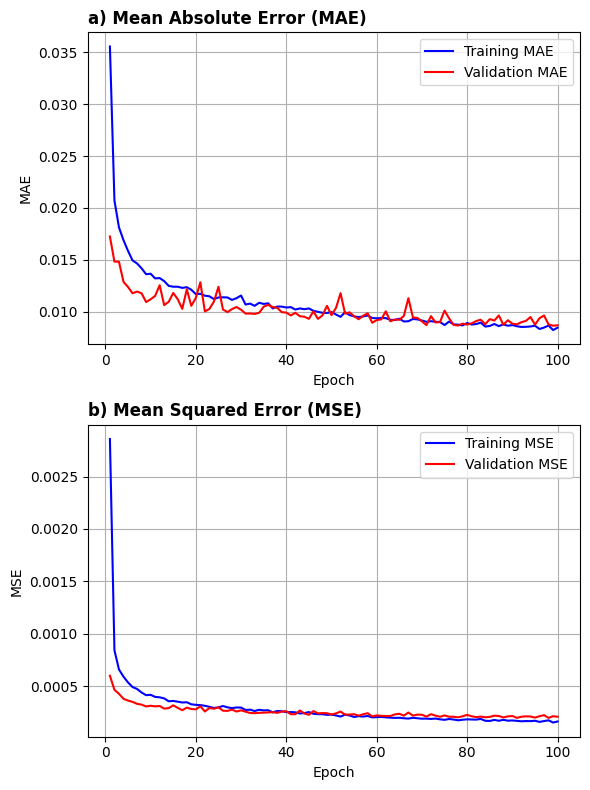

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to create the DNN model
def create_dnn(input_shape, dropout_rate=0.1):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Output layer for regression
    ])
    return model

# Compile the model
def compile_dnn(model, learning_rate=0.001):
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',  # Mean Squared Error for regression
                  metrics=['mae'])  # Mean Absolute Error as an additional metric
    return model

# Store cross-validation results
cv_results = []

# Perform 10-Fold Spatial Cross-Validation
for fold_split in spatial_cv_splits:
    fold = fold_split["fold"]
    X_train_fold = fold_split["X_train"]
    y_train_fold = fold_split["y_train"]
    X_val_fold = fold_split["X_val"]
    y_val_fold = fold_split["y_val"]

    print(f"\n🔹 Training Fold {fold} (Train on 9 folds, Validate on 1 fold)...")

    # Define input shape
    input_shape = X_train_fold.shape[1]

    # Create and compile the model
    dnn_model = create_dnn(input_shape)
    dnn_model = compile_dnn(dnn_model)

    # Train the model
    history = dnn_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=1
    )

    # Evaluate the model on the validation set
    val_loss, val_mae = dnn_model.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Make predictions on the validation set
    y_pred_val = dnn_model.predict(X_val_fold)

    # Calculate regression metrics
    mse = mean_squared_error(y_val_fold, y_pred_val)
    mae = mean_absolute_error(y_val_fold, y_pred_val)
    r2 = r2_score(y_val_fold, y_pred_val)

    # Store results
    cv_results.append({
        "Fold": fold,
        "Validation MSE": mse,
        "Validation MAE": mae,
        "Validation R²": r2
    })

    print(f"✅ Fold {fold} Results: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# Convert results to DataFrame and display
cv_results_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Results:\n", cv_results_df)

# Train Final Model on Full Training Data
print("\n🚀 Training Final Model on Full Training Data...")
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])
y_train_full = y_train

input_shape = X_train_full.shape[1]
final_model = create_dnn(input_shape)
final_model = compile_dnn(final_model)

history_final = final_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_final_with_indices, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Evaluate the final model on the test set
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on the test set
y_pred_test = final_model.predict(X_test_final_with_indices)

# Calculate final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test metrics
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save the final model
final_model.save('final_dnn_regression_model.h5')

# Plot training history
import matplotlib.pyplot as plt

def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot final model training history
plot_training_validation_metrics(history_final)


* the MAE and MSE curves indicate stable learning after arount 40-50 epochs.
* the validation loss does not spike, meaning no severe overfitting is observed.
* the learning rate seems appropriate, as the model gradually converges without sudden fluctuations.

### Hyperparameter Optimization using Grid Search

Grid Search Process:
* Train multiple models using different HP.
* Peroform 10-fold spatila cross validation to evalulate each model.
* Select the best-performing model based on lowest MSE.
* Train the final model using Best HP.
* Evaluate the final model on the test dataset.

# Next steps
* Once the best model is identified, train it on the full training dataset.
* validate on X_val_final_with_indices
* Test the final model on X_test_final_with_indices

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
import matplotlib.pyplot as plt

# Define hyperparameter grid
param_grid = {
    "hidden_layers": [4],  # Number of hidden layers
    "neurons": [32, 64, 128],   # Number of neurons per layer
    "dropout_rate": [0.1, 0.2, 0.3],
    "learning_rate": [0.001],
    "batch_size": [32],
    "epochs": [50, 70]
}

# Generate all combinations of hyperparameters
param_combinations = list(product(
    param_grid["hidden_layers"],
    param_grid["neurons"],
    param_grid["dropout_rate"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["epochs"]
))

# Initialize variables to store the best model
best_params = None
best_mae = float("inf")  # Start with a high MAE value
results = []

# Loop through each hyperparameter combination
for i, (hidden_layers, neurons, dropout_rate, learning_rate, batch_size, epochs) in enumerate(param_combinations, start=1):
    print(f"\n🔹 Training Model {i}/{len(param_combinations)}: "
          f"Hidden Layers: {hidden_layers}, Neurons: {neurons}, Dropout: {dropout_rate}, "
          f"LR: {learning_rate}, Batch Size: {batch_size}, Epochs: {epochs}")

    fold_mse, fold_mae, fold_r2 = [], [], []

    # **Perform 10-Fold Spatial Cross-Validation**
    for fold in range(10):
        print(f"➡️ Fold {fold}: Training on 9 folds, validating on 1 fold...")

        # Train on 9 folds, validate on 1 fold
        train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
        val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

        # Extract X and y, drop the spatial fold column
        X_train_fold = train_data.drop(columns=["spatial_fold"])
        y_train_fold = y_train.loc[X_train_fold.index]

        X_val_fold = val_data.drop(columns=["spatial_fold"])
        y_val_fold = y_train.loc[X_val_fold.index]

        # Build the model dynamically
        model = Sequential()
        model.add(Dense(neurons, activation='relu', input_shape=(X_train_fold.shape[1],)))
        model.add(Dropout(dropout_rate))

        for _ in range(hidden_layers - 1):  # Add additional hidden layers
            model.add(Dense(neurons // 2, activation='relu'))
            model.add(Dropout(dropout_rate))

        model.add(Dense(1, activation='linear'))  # Regression output

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=learning_rate),
                      loss='mse', metrics=['mae'])

        # Train the model
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0  # Set to 1 to see logs
        )

        # Make predictions on validation fold
        y_val_pred = model.predict(X_val_fold)

        # Compute metrics for this fold
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mae = mean_absolute_error(y_val_fold, y_val_pred)
        r2 = r2_score(y_val_fold, y_val_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    # **Compute Average Metrics Across 10 Folds**
    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    # Store results
    results.append({
        "Hidden Layers": hidden_layers,
        "Neurons": neurons,
        "Dropout Rate": dropout_rate,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Avg MSE": avg_mse,
        "Avg MAE": avg_mae,
        "Avg R2": avg_r2
    })

    print(f"✔ Model {i} - Avg MSE: {avg_mse:.4f}, Avg MAE: {avg_mae:.4f}, Avg R²: {avg_r2:.4f}")

    # Update best parameters if the current model is better
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_params = {
            "Hidden Layers": hidden_layers,
            "Neurons": neurons,
            "Dropout Rate": dropout_rate,
            "Learning Rate": learning_rate,
            "Batch Size": batch_size,
            "Epochs": epochs
        }


🔹 Training Model 1/18: Hidden Layers: 4, Neurons: 32, Dropout: 0.1, LR: 0.001, Batch Size: 32, Epochs: 50
➡️ Fold 0: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
➡️ Fold 1: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
➡️ Fold 2: Training on 9 folds, validating on 1 fold...


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
➡️ Fold 8: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
➡️ Fold 9: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
✔ Model 18 - Avg MSE: 0.0005, Avg MAE: 0.0159, Avg R²: 0.0804


In [ ]:
# Convert results to a DataFrame and sort by best MAE
df_results = pd.DataFrame(results).sort_values(by="Avg MAE", ascending=True)

# Save results
df_results.to_csv("hyperparameter_tuning_results.csv", index=False)

print("\n✅ Best Hyperparameters (Lowest MAE):")
print(best_params)

# Display the best hyperparameters
# import ace_tools as tools
# tools.display_dataframe_to_user(name="Hyperparameter Tuning Results", dataframe=df_results)



✅ Best Hyperparameters (Lowest MAE):
{'Hidden Layers': 4, 'Neurons': 128, 'Dropout Rate': 0.2, 'Learning Rate': 0.001, 'Batch Size': 32, 'Epochs': 70}


## Explanation of the code
* Hyperparameter Tuning
  * ries different numbers of hidden layers
  * Tests different dropout rates
  * Optmizes learning rate
  * Adjust batch size and epochs
  * Saves MSE, MAE, and R^2 for all models.

* 10-Fold Spatial CV
    * Trains the model on 9 folds, validates on 1 fold.
    * Computes the average metrics across 10 folds.
    * Saves the best model with the lowest MAE.

In [ ]:
# Load the saved hyperparameter tuning results
df_results = pd.read_csv("hyperparameter_tuning_results.csv")
df_results

,Hidden Layers,Neurons,Dropout Rate,Learning Rate,Batch Size,Epochs,Avg MSE,Avg MAE,Avg R2
0,4,128,0.2,0.001,32,70,0.000574,0.014481,0.124686
1,4,64,0.1,0.001,32,70,0.000591,0.014576,0.034509
2,4,128,0.1,0.001,32,50,0.000602,0.014772,-0.007103
3,4,128,0.1,0.001,32,70,0.000609,0.014836,-0.059859
4,4,32,0.1,0.001,32,70,0.000595,0.015103,0.094032
5,4,32,0.1,0.001,32,50,0.000584,0.015363,0.082626
6,4,64,0.1,0.001,32,50,0.000605,0.015390,0.010855
7,4,64,0.2,0.001,32,50,0.000582,0.015626,0.053184
8,4,128,0.3,0.001,32,50,0.000561,0.015679,-0.038019
9,4,128,0.3,0.001,32,70,0.000547,0.015899,0.080428


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🚀 Training Final Model on Full Training Data...
Epoch 1/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0206 - mae: 0.0835 - val_loss: 8.9204e-04 - val_mae: 0.0197
Epoch 2/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - mae: 0.0258 - val_loss: 8.0012e-04 - val_mae: 0.0204
Epoch 3/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.9496e-04 - mae: 0.0225 - val_loss: 7.1852e-04 - val_mae: 0.0188
Epoch 4/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.4606e-04 - mae: 0.0214 - val_loss: 6.2379e-04 - val_mae: 0.0176
Epoch 5/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.7255e-04 - mae: 0.0193 - val_loss: 5.7267e-04 - val_mae: 0.0161
Epoch 6/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8475e-04 - mae: 0.0180 - val_loss: 4.8378e-04 - val_mae: 0.0153
Epoch 7/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.5375e-04 - mae: 0.0171 - val_loss: 4.8584e-04 - val_mae: 0.0151
Epoch 8/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0559e-04 - mae


🎯 Final Model Performance on Test Data:
Test MSE: 0.000264
Test MAE: 0.010654
Test R² Score: 0.7572

✅ Final model saved successfully!


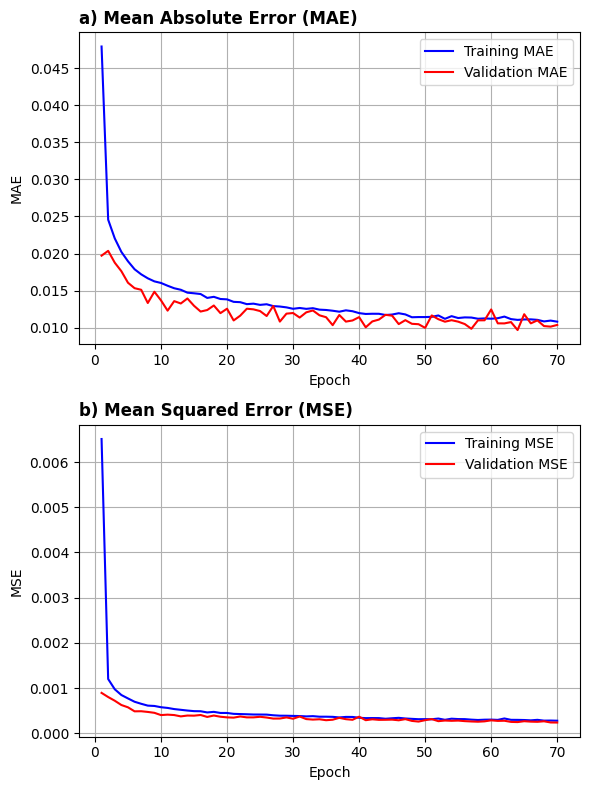

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ✅ Best Hyperparameters (from tuning)
best_hyperparams = {
    "hidden_layers": 4,
    "neurons": 128,
    "dropout_rate": 0.2,
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 70
}

# Extract best hyperparameters
hidden_layers = best_hyperparams["hidden_layers"]
neurons = best_hyperparams["neurons"]
dropout_rate = best_hyperparams["dropout_rate"]
learning_rate = best_hyperparams["learning_rate"]
batch_size = best_hyperparams["batch_size"]
epochs = best_hyperparams["epochs"]

# Build final model
final_model = Sequential()
final_model.add(Dense(neurons, activation='relu', input_shape=(X_train_final_with_indices.shape[1] - 1,)))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 1):  # Add additional hidden layers dynamically
    final_model.add(Dense(neurons // 2, activation='relu'))
    final_model.add(Dropout(dropout_rate))

final_model.add(Dense(1, activation='linear'))  # Output layer for regression

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Train final model on FULL TRAINING DATA
print("\n🚀 Training Final Model on Full Training Data...")
history_final = final_model.fit(
    X_train_final_with_indices.drop(columns=["spatial_fold"]), y_train,  # Drop spatial_fold
    validation_data=(X_val_final_with_indices, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Evaluate final model on test data
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on test set
y_pred_test = final_model.predict(X_test_final_with_indices)

# Compute final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test performance
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.6f}")
print(f"Test MAE: {mae_test:.6f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save final model
final_model.save('final_dnn_regression_model.h5')
print("\n✅ Final model saved successfully!")

# Function to plot training history (MAE & MSE)
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot training curves
plot_training_validation_metrics(history_final)


# BiRNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

*This script trains BiRNN on 9 folds, validates on 1 fold, and optimizes hp*

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
import matplotlib.pyplot as plt

# Define hyperparameter grid
param_grid = {
    "hidden_layers": [2, 4],  # Number of BiRNN layers
    "neurons": [64, 128],        # Neurons per layer
    "dropout_rate": [0.1, 0.2],
    "learning_rate": [0.001],
    "batch_size": [32],
    "epochs": [50, 70]
}

# Generate all combinations of hyperparameters
param_combinations = list(product(
    param_grid["hidden_layers"],
    param_grid["neurons"],
    param_grid["dropout_rate"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["epochs"]
))

# Initialize variables to store the best model
best_params = None
best_mae = float("inf")  # Start with a high MAE value
results = []

# Loop through each hyperparameter combination
for i, (hidden_layers, neurons, dropout_rate, learning_rate, batch_size, epochs) in enumerate(param_combinations, start=1):
    print(f"\n🔹 Training Model {i}/{len(param_combinations)}: "
          f"Hidden Layers: {hidden_layers}, Neurons: {neurons}, Dropout: {dropout_rate}, "
          f"LR: {learning_rate}, Batch Size: {batch_size}, Epochs: {epochs}")

    fold_mse, fold_mae, fold_r2 = [], [], []

    # **Perform 10-Fold Spatial Cross-Validation**
    for fold in range(10):
        print(f"➡️ Fold {fold}: Training on 9 folds, validating on 1 fold...")

        # Train on 9 folds, validate on 1 fold
        train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
        val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

        # Extract X and y, drop the spatial fold column
        X_train_fold = train_data.drop(columns=["spatial_fold"]).values
        y_train_fold = y_train.loc[train_data.index]

        X_val_fold = val_data.drop(columns=["spatial_fold"]).values
        y_val_fold = y_train.loc[val_data.index]

        # **RESHAPE INPUT to 3D** (samples, timesteps=1, features)
        X_train_fold = X_train_fold.reshape((X_train_fold.shape[0], 1, X_train_fold.shape[1]))
        X_val_fold = X_val_fold.reshape((X_val_fold.shape[0], 1, X_val_fold.shape[1]))

        # Build the BiRNN model
        model = Sequential()
        model.add(Bidirectional(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_train_fold.shape[2]))))
        model.add(Dropout(dropout_rate))

        for _ in range(hidden_layers - 2):  # Additional BiRNN layers
            model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
            model.add(Dropout(dropout_rate))

        model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))  # Last RNN layer
        model.add(Dense(1, activation='linear'))  # Regression output

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=learning_rate),
                      loss='mse', metrics=['mae'])

        # Train the model
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        # Make predictions on validation fold
        y_val_pred = model.predict(X_val_fold)

        # Compute metrics for this fold
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mae = mean_absolute_error(y_val_fold, y_val_pred)
        r2 = r2_score(y_val_fold, y_val_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    # **Compute Average Metrics Across 10 Folds**
    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    # Store results
    results.append({
        "Hidden Layers": hidden_layers,
        "Neurons": neurons,
        "Dropout Rate": dropout_rate,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Avg MSE": avg_mse,
        "Avg MAE": avg_mae,
        "Avg R2": avg_r2
    })

    print(f"✔ Model {i} - Avg MSE: {avg_mse:.4f}, Avg MAE: {avg_mae:.4f}, Avg R²: {avg_r2:.4f}")

    # Update best parameters if the current model is better
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_params = {
            "Hidden Layers": hidden_layers,
            "Neurons": neurons,
            "Dropout Rate": dropout_rate,
            "Learning Rate": learning_rate,
            "Batch Size": batch_size,
            "Epochs": epochs
        }

# Convert results to a DataFrame and sort by best MAE
df_results = pd.DataFrame(results).sort_values(by="Avg MAE", ascending=True)

# Save results
df_results.to_csv("birnn_hyperparameter_tuning_results.csv", index=False)

print("\n✅ Best Hyperparameters (Lowest MAE):")
print(best_params)



🔹 Training Model 1/16: Hidden Layers: 2, Neurons: 64, Dropout: 0.1, LR: 0.001, Batch Size: 32, Epochs: 50
➡️ Fold 0: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
➡️ Fold 1: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
➡️ Fold 2: Training on 9 folds, validating on 1 fold...


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
➡️ Fold 8: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
➡️ Fold 9: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step
✔ Model 16 - Avg MSE: 0.0006, Avg MAE: 0.0142, Avg R²: 0.1057

✅ Best Hyperparameters (Lowest MAE):
{'Hidden Layers': 4, 'Neurons': 128, 'Dropout Rate': 0.2, 'Learning Rate': 0.001, 'Batch Size': 32, 'Epochs': 50}


after obtaining best hp, train the final BiRNN model.

In [ ]:
# ✅ Best Hyperparameters (from tuning)
best_hyperparams = best_params

# Extract best hyperparameters
hidden_layers = best_hyperparams["Hidden Layers"]
neurons = best_hyperparams["Neurons"]
dropout_rate = best_hyperparams["Dropout Rate"]
learning_rate = best_hyperparams["Learning Rate"]
batch_size = best_hyperparams["Batch Size"]
epochs = best_hyperparams["Epochs"]

# Build final model
final_model = Sequential()
final_model.add(Bidirectional(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_train_final_with_indices.shape[1] - 1))))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 2):
    final_model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
    final_model.add(Dropout(dropout_rate))

final_model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))
final_model.add(Dense(1, activation='linear'))

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Train final model on FULL TRAINING DATA
history_final = final_model.fit(
    X_train_final_with_indices.drop(columns=["spatial_fold"]).values.reshape((-1, 1, X_train_final_with_indices.shape[1] - 1)),
    y_train,
    validation_data=(X_val_final_with_indices.values.reshape((-1, 1, X_val_final_with_indices.shape[1])), y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Save final model
final_model.save('final_birnn_regression_model.h5')


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0133 - mae: 0.0735 - val_loss: 8.9347e-04 - val_mae: 0.0222
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0014 - mae: 0.0268 - val_loss: 7.3199e-04 - val_mae: 0.0195
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.6167e-04 - mae: 0.0222 - val_loss: 6.2935e-04 - val_mae: 0.0176
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.8219e-04 - mae: 0.0198 - val_loss: 5.6988e-04 - val_mae: 0.0182
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 7.2337e-04 - mae: 0.0189 - val_loss: 5.3481e-04 - val_mae: 0.0167
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.5758e-04 - mae: 0.0176 - val_loss: 4.5436e-04 - val_mae: 0.0148
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.3674e-04 - mae: 0.0169 - val_loss: 4.2519e-04 - val_mae: 0.0152
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5.6459e-04 - mae: 0.0160 - val_loss: 4.0329e-04 - val_mae: 0.0126
Epoch 9


📊 Evaluating Final BiRNN Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step

🎯 Final BiRNN Model Performance on Test Data:
Test MSE: 0.000278
Test MAE: 0.010352
Test R² Score: 0.7440

✅ Test results saved successfully!


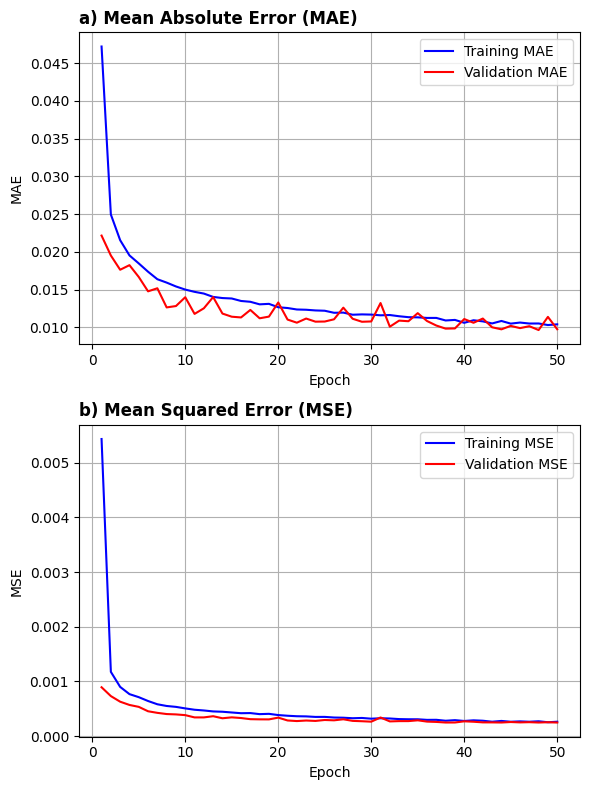

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate final model on test data
print("\n📊 Evaluating Final BiRNN Model on Test Data...")
test_loss, test_mae = final_model.evaluate(
    X_test_final_with_indices.values.reshape((-1, 1, X_test_final_with_indices.shape[1])),
    y_test,
    verbose=0
)

# Make predictions on the test set
y_pred_test = final_model.predict(X_test_final_with_indices.values.reshape((-1, 1, X_test_final_with_indices.shape[1])))

# Compute final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display final test performance
print("\n🎯 Final BiRNN Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.6f}")
print(f"Test MAE: {mae_test:.6f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save test results
test_results = {
    "Test MSE": mse_test,
    "Test MAE": mae_test,
    "Test R²": r2_test
}
df_test_results = pd.DataFrame([test_results])
df_test_results.to_csv("birnn_test_results.csv", index=False)

print("\n✅ Test results saved successfully!")

# Function to plot training history (MAE & MSE)
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot training curves for final model
plot_training_validation_metrics(history_final)


# RNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
import matplotlib.pyplot as plt

# Define hyperparameter grid
param_grid = {
    "hidden_layers": [2, 4],  # Number of RNN layers
    "neurons": [64, 128],     # Neurons per layer
    "dropout_rate": [0.1, 0.2],
    "learning_rate": [0.001],
    "batch_size": [32],
    "epochs": [50, 70]
}

# Generate all combinations of hyperparameters
param_combinations = list(product(
    param_grid["hidden_layers"],
    param_grid["neurons"],
    param_grid["dropout_rate"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["epochs"]
))

# Initialize variables to store the best model
best_params = None
best_mae = float("inf")  # Start with a high MAE value
results = []

# Loop through each hyperparameter combination
for i, (hidden_layers, neurons, dropout_rate, learning_rate, batch_size, epochs) in enumerate(param_combinations, start=1):
    print(f"\n🔹 Training Model {i}/{len(param_combinations)}: "
          f"Hidden Layers: {hidden_layers}, Neurons: {neurons}, Dropout: {dropout_rate}, "
          f"LR: {learning_rate}, Batch Size: {batch_size}, Epochs: {epochs}")

    fold_mse, fold_mae, fold_r2 = [], [], []

    # **Perform 10-Fold Spatial Cross-Validation**
    for fold in range(10):
        print(f"➡️ Fold {fold}: Training on 9 folds, validating on 1 fold...")

        # Train on 9 folds, validate on 1 fold
        train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
        val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

        # Extract X and y, drop the spatial fold column
        X_train_fold = train_data.drop(columns=["spatial_fold"]).values
        y_train_fold = y_train.loc[train_data.index]

        X_val_fold = val_data.drop(columns=["spatial_fold"]).values
        y_val_fold = y_train.loc[val_data.index]

        # **RESHAPE INPUT to 3D** (samples, timesteps=1, features)
        X_train_fold = X_train_fold.reshape((X_train_fold.shape[0], 1, X_train_fold.shape[1]))
        X_val_fold = X_val_fold.reshape((X_val_fold.shape[0], 1, X_val_fold.shape[1]))

        # Build the SimpleRNN model
        model = Sequential()
        model.add(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_train_fold.shape[2])))
        model.add(Dropout(dropout_rate))

        for _ in range(hidden_layers - 2):  # Additional RNN layers
            model.add(SimpleRNN(neurons // 2, activation='relu', return_sequences=True))
            model.add(Dropout(dropout_rate))

        model.add(SimpleRNN(neurons // 4, activation='relu', return_sequences=False))  # Last RNN layer
        model.add(Dense(1, activation='linear'))  # Regression output

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=learning_rate),
                      loss='mse', metrics=['mae'])

        # Train the model
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        # Make predictions on validation fold
        y_val_pred = model.predict(X_val_fold)

        # Compute metrics for this fold
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mae = mean_absolute_error(y_val_fold, y_val_pred)
        r2 = r2_score(y_val_fold, y_val_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    # **Compute Average Metrics Across 10 Folds**
    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    # Store results
    results.append({
        "Hidden Layers": hidden_layers,
        "Neurons": neurons,
        "Dropout Rate": dropout_rate,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Avg MSE": avg_mse,
        "Avg MAE": avg_mae,
        "Avg R2": avg_r2
    })

    print(f"✔ Model {i} - Avg MSE: {avg_mse:.4f}, Avg MAE: {avg_mae:.4f}, Avg R²: {avg_r2:.4f}")

    # Update best parameters if the current model is better
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_params = {
            "Hidden Layers": hidden_layers,
            "Neurons": neurons,
            "Dropout Rate": dropout_rate,
            "Learning Rate": learning_rate,
            "Batch Size": batch_size,
            "Epochs": epochs
        }

# Convert results to a DataFrame and sort by best MAE
df_results = pd.DataFrame(results).sort_values(by="Avg MAE", ascending=True)

# Save results
df_results.to_csv("rnn_hyperparameter_tuning_results.csv", index=False)

print("\n✅ Best Hyperparameters (Lowest MAE):")
print(best_params)



🔹 Training Model 1/16: Hidden Layers: 2, Neurons: 64, Dropout: 0.1, LR: 0.001, Batch Size: 32, Epochs: 50
➡️ Fold 0: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
➡️ Fold 1: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
➡️ Fold 2: Training on 9 folds, validating on 1 fold...


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
➡️ Fold 8: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
➡️ Fold 9: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
✔ Model 16 - Avg MSE: 0.0006, Avg MAE: 0.0152, Avg R²: -0.0108

✅ Best Hyperparameters (Lowest MAE):
{'Hidden Layers': 4, 'Neurons': 64, 'Dropout Rate': 0.1, 'Learning Rate': 0.001, 'Batch Size': 32, 'Epochs': 50}


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam



# Extract best hyperparameters
hidden_layers = 4
neurons = 64
dropout_rate = 0.1
learning_rate = 0.001
batch_size = 32
epochs = 50

# Prepare full training and validation datasets
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"]).values
y_train_full = y_train

X_val_full = X_val_final_with_indices.values
y_val_full = y_val

# **RESHAPE INPUT to 3D** (samples, timesteps=1, features)
X_train_full = X_train_full.reshape((X_train_full.shape[0], 1, X_train_full.shape[1]))
X_val_full = X_val_full.reshape((X_val_full.shape[0], 1, X_val_full.shape[1]))

# Build final RNN model
final_model = Sequential()
final_model.add(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_train_full.shape[2])))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 2):  # Additional RNN layers
    final_model.add(SimpleRNN(neurons // 2, activation='relu', return_sequences=True))
    final_model.add(Dropout(dropout_rate))

final_model.add(SimpleRNN(neurons // 4, activation='relu', return_sequences=False))  # Last RNN layer
final_model.add(Dense(1, activation='linear'))  # Regression output

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Train final model on FULL TRAINING DATA
print("\n🚀 Training Final RNN Model on Full Training Data...")
history_final = final_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_full, y_val_full),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Save final model
final_model.save('final_rnn_regression_model.h5')
print("\n✅ Final RNN model saved successfully!")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 Training Final RNN Model on Full Training Data...
Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0057 - mae: 0.0496 - val_loss: 8.3900e-04 - val_mae: 0.0192
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0011 - mae: 0.0240 - val_loss: 6.7290e-04 - val_mae: 0.0169
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.7347e-04 - mae: 0.0206 - val_loss: 5.5610e-04 - val_mae: 0.0162
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.2366e-04 - mae: 0.0187 - val_loss: 4.8408e-04 - val_mae: 0.0144
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.4787e-04 - mae: 0.0170 - val_loss: 4.5027e-04 - val_mae: 0.0139
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 6.2231e-04 - mae: 0.0168 - val_loss: 4.0786e-04 - val_mae: 0.0133
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.5250e-04 - mae: 0.0158 - val_loss: 3.9408e-04 - val_mae: 0.0132
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 5.5366


✅ Final RNN model saved successfully!



📊 Evaluating Final RNN Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

🎯 Final RNN Model Performance on Test Data:
Test MSE: 0.000291
Test MAE: 0.010342
Test R² Score: 0.7325

✅ Test results saved successfully!


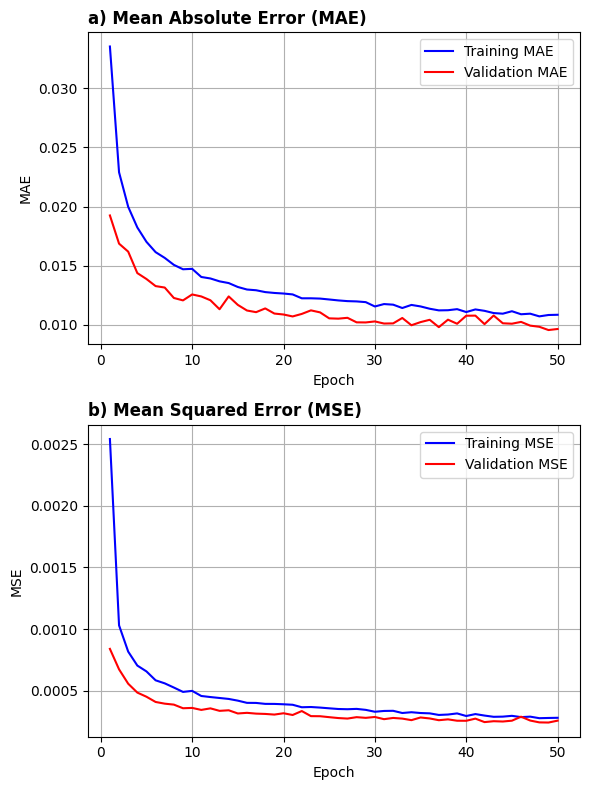

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare test data
X_test_full = X_test_final_with_indices.values.reshape((-1, 1, X_test_final_with_indices.shape[1]))
y_test_full = y_test

# Evaluate final model on test data
print("\n📊 Evaluating Final RNN Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_full, y_test_full, verbose=0)

# Make predictions on the test set
y_pred_test = final_model.predict(X_test_full)

# Compute final test metrics
mse_test = mean_squared_error(y_test_full, y_pred_test)
mae_test = mean_absolute_error(y_test_full, y_pred_test)
r2_test = r2_score(y_test_full, y_pred_test)

# Display final test performance
print("\n🎯 Final RNN Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.6f}")
print(f"Test MAE: {mae_test:.6f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save test results
test_results = {
    "Test MSE": mse_test,
    "Test MAE": test_mae,
    "Test R²": r2_test
}
df_test_results = pd.DataFrame([test_results])
df_test_results.to_csv("rnn_test_results.csv", index=False)

print("\n✅ Test results saved successfully!")

# Function to plot training history (MAE & MSE)
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot training curves for final model
plot_training_validation_metrics(history_final)


# Encoder-Decoder BiRNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, Bidirectional, RepeatVector
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
import matplotlib.pyplot as plt

# Define hyperparameter grid
param_grid = {
    "hidden_layers": [6],  # Number of Encoder-Decoder BiRNN layers
    "neurons": [128],     # Neurons per layer
    "dropout_rate": [0.1, 0.2],
    "learning_rate": [0.001],
    "batch_size": [32],
    "epochs": [50]
}

# Generate all combinations of hyperparameters
param_combinations = list(product(
    param_grid["hidden_layers"],
    param_grid["neurons"],
    param_grid["dropout_rate"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["epochs"]
))

# Initialize variables to store the best model
best_params = None
best_mae = float("inf")  # Start with a high MAE value
results = []

# Loop through each hyperparameter combination
for i, (hidden_layers, neurons, dropout_rate, learning_rate, batch_size, epochs) in enumerate(param_combinations, start=1):
    print(f"\n🔹 Training Model {i}/{len(param_combinations)}: "
          f"Hidden Layers: {hidden_layers}, Neurons: {neurons}, Dropout: {dropout_rate}, "
          f"LR: {learning_rate}, Batch Size: {batch_size}, Epochs: {epochs}")

    fold_mse, fold_mae, fold_r2 = [], [], []

    # **Perform 10-Fold Spatial Cross-Validation**
    for fold in range(10):
        print(f"➡️ Fold {fold}: Training on 9 folds, validating on 1 fold...")

        # Train on 9 folds, validate on 1 fold
        train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
        val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

        # Extract X and y, drop the spatial fold column
        X_train_fold = train_data.drop(columns=["spatial_fold"]).values
        y_train_fold = y_train.loc[train_data.index]

        X_val_fold = val_data.drop(columns=["spatial_fold"]).values
        y_val_fold = y_train.loc[val_data.index]

        # **RESHAPE INPUT to 3D** (samples, timesteps=1, features)
        X_train_fold = X_train_fold.reshape((X_train_fold.shape[0], 1, X_train_fold.shape[1]))
        X_val_fold = X_val_fold.reshape((X_val_fold.shape[0], 1, X_val_fold.shape[1]))

        # Build the Encoder-Decoder BiRNN model
        model = Sequential()

        # Encoder
        model.add(Bidirectional(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_train_fold.shape[2]))))
        model.add(Dropout(dropout_rate))

        for _ in range(hidden_layers - 2):  # Additional BiRNN layers in the encoder
            model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
            model.add(Dropout(dropout_rate))

        # **Last RNN Layer in Encoder - Use return_sequences=False**
        model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))
        model.add(Dropout(dropout_rate))

        # **Flatten output to 2D before RepeatVector**
        model.add(Dense(neurons // 4, activation="relu"))  # Ensure output is 2D

        # Repeat vector for decoder (Fixing dimension mismatch)
        model.add(RepeatVector(1))

        # Decoder
        for _ in range(hidden_layers - 2):
            model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
            model.add(Dropout(dropout_rate))

        # Last RNN layer in Decoder
        model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))

        # Output layer
        model.add(Dense(1, activation='linear'))  # Regression output

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=learning_rate),
                      loss='mse', metrics=['mae'])

        # Train the model
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        # Make predictions on validation fold
        y_val_pred = model.predict(X_val_fold)

        # Compute metrics for this fold
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mae = mean_absolute_error(y_val_fold, y_val_pred)
        r2 = r2_score(y_val_fold, y_val_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    # **Compute Average Metrics Across 10 Folds**
    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    # Store results
    results.append({
        "Hidden Layers": hidden_layers,
        "Neurons": neurons,
        "Dropout Rate": dropout_rate,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Avg MSE": avg_mse,
        "Avg MAE": avg_mae,
        "Avg R2": avg_r2
    })

    print(f"✔ Model {i} - Avg MSE: {avg_mse:.4f}, Avg MAE: {avg_mae:.4f}, Avg R²: {avg_r2:.4f}")

    # Update best parameters if the current model is better
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_params = {
            "Hidden Layers": hidden_layers,
            "Neurons": neurons,
            "Dropout Rate": dropout_rate,
            "Learning Rate": learning_rate,
            "Batch Size": batch_size,
            "Epochs": epochs
        }

# Convert results to a DataFrame and sort by best MAE
df_results = pd.DataFrame(results).sort_values(by="Avg MAE", ascending=True)

# Save results
df_results.to_csv("encoder_decoder_birnn_hyperparameter_tuning_results.csv", index=False)

print("\n✅ Best Hyperparameters (Lowest MAE):")
print(best_params)



🔹 Training Model 1/2: Hidden Layers: 6, Neurons: 128, Dropout: 0.1, LR: 0.001, Batch Size: 32, Epochs: 50
➡️ Fold 0: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step
➡️ Fold 1: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step
➡️ Fold 2: Training on 9 folds, validating on 1 fold...


...

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
➡️ Fold 8: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step
➡️ Fold 9: Training on 9 folds, validating on 1 fold...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step
✔ Model 2 - Avg MSE: 0.0006, Avg MAE: 0.0168, Avg R²: -0.1710

✅ Best Hyperparameters (Lowest MAE):
{'Hidden Layers': 6, 'Neurons': 128, 'Dropout Rate': 0.1, 'Learning Rate': 0.001, 'Batch Size': 32, 'Epochs': 50}


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, Bidirectional, RepeatVector
from tensorflow.keras.optimizers import Adam

best_hyperparams = {
    "Hidden Layers": 6,
    "Neurons": 512,
    "Dropout Rate": 0.1,
    "Learning Rate": 0.001,
    "Batch Size": 32,
    "Epochs": 50
}

# ✅ Load best hyperparameters
hidden_layers = best_hyperparams["Hidden Layers"]
neurons = best_hyperparams["Neurons"]
dropout_rate = best_hyperparams["Dropout Rate"]
learning_rate = best_hyperparams["Learning Rate"]
batch_size = best_hyperparams["Batch Size"]
epochs = best_hyperparams["Epochs"]

# Prepare full training dataset
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"]).values
y_train_full = y_train

X_val_full = X_val_final_with_indices.values
y_val_full = y_val

# **RESHAPE INPUT to 3D** (samples, timesteps=1, features)
X_train_full = X_train_full.reshape((X_train_full.shape[0], 1, X_train_full.shape[1]))
X_val_full = X_val_full.reshape((X_val_full.shape[0], 1, X_val_full.shape[1]))

# Build the Encoder-Decoder BiRNN model
final_model = Sequential()

# Encoder
final_model.add(Bidirectional(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_train_full.shape[2]))))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 2):  # Additional BiRNN layers in the encoder
    final_model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
    final_model.add(Dropout(dropout_rate))

# **Last RNN Layer in Encoder - Use return_sequences=False**
final_model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))
final_model.add(Dropout(dropout_rate))

# **Flatten output to 2D before RepeatVector**
final_model.add(Dense(neurons // 4, activation="relu"))  # Ensure output is 2D

# Repeat vector for decoder (Fixing dimension mismatch)
final_model.add(RepeatVector(1))

# Decoder
for _ in range(hidden_layers - 2):
    final_model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
    final_model.add(Dropout(dropout_rate))

# Last RNN layer in Decoder
final_model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))

# Output layer
final_model.add(Dense(1, activation='linear'))  # Regression output

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Train final model on FULL TRAINING DATA
print("\n🚀 Training Final Encoder-Decoder BiRNN Model on Full Training Data...")
history_final = final_model.fit(
    X_train_full, y_train_full,
    validation_data=(X_val_full, y_val_full),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Save final model
final_model.save('final_encoder_decoder_birnn_model.h5')
print("\n✅ Final Encoder-Decoder BiRNN Model saved successfully!")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 Training Final Encoder-Decoder BiRNN Model on Full Training Data...
Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 53s 94ms/step - loss: 0.0016 - mae: 0.0251 - val_loss: 5.2545e-04 - val_mae: 0.0182
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - loss: 5.3472e-04 - mae: 0.0157 - val_loss: 5.8589e-04 - val_mae: 0.0173
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - loss: 5.3272e-04 - mae: 0.0156 - val_loss: 4.2802e-04 - val_mae: 0.0155
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - loss: 4.2466e-04 - mae: 0.0139 - val_loss: 3.5613e-04 - val_mae: 0.0122
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - loss: 4.0967e-04 - mae: 0.0133 - val_loss: 3.5432e-04 - val_mae: 0.0118
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - loss: 4.1445e-04 - mae: 0.0131 - val_loss: 3.7106e-04 - val_mae: 0.0117
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 3.8046e-04 - mae: 0.0128 - val_loss: 3.1539e-04 - val_mae: 0.0110
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━


✅ Final Encoder-Decoder BiRNN Model saved successfully!



📊 Evaluating Final Encoder-Decoder BiRNN Model on Test Data...
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step

🎯 Final Encoder-Decoder BiRNN Model Performance on Test Data:
Test MSE: 0.000317
Test MAE: 0.011321
Test R² Score: 0.7083

✅ Test results saved successfully!


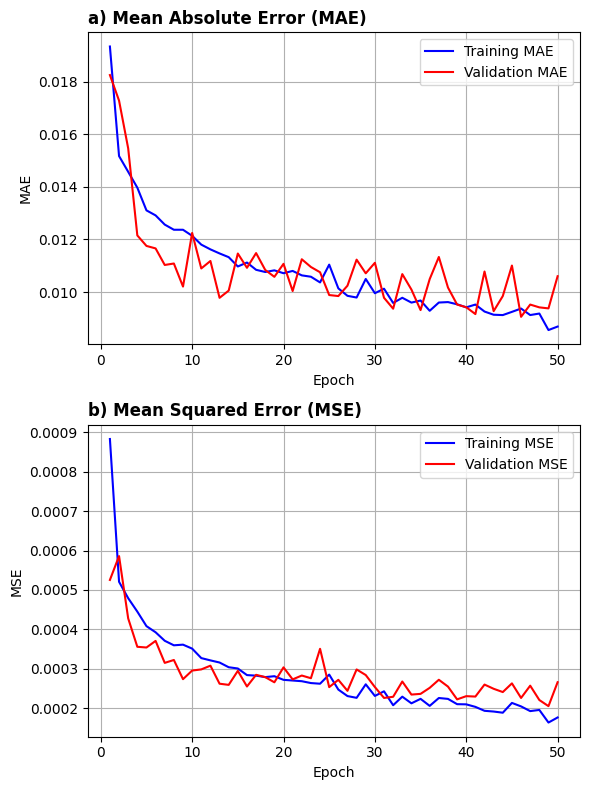

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ✅ Prepare test dataset
X_test_full = X_test_final_with_indices.values
y_test_full = y_test

# **RESHAPE INPUT to 3D** (samples, timesteps=1, features)
X_test_full = X_test_full.reshape((X_test_full.shape[0], 1, X_test_full.shape[1]))

# ✅ Evaluate final model on test data
print("\n📊 Evaluating Final Encoder-Decoder BiRNN Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_full, y_test_full, verbose=0)

# ✅ Make predictions on the test set
y_pred_test = final_model.predict(X_test_full)

# ✅ Compute final test metrics
mse_test = mean_squared_error(y_test_full, y_pred_test)
mae_test = mean_absolute_error(y_test_full, y_pred_test)
r2_test = r2_score(y_test_full, y_pred_test)

# ✅ Display final test performance
print("\n🎯 Final Encoder-Decoder BiRNN Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.6f}")
print(f"Test MAE: {mae_test:.6f}")
print(f"Test R² Score: {r2_test:.4f}")

# ✅ Save test results
test_results = {
    "Test MSE": mse_test,
    "Test MAE": mae_test,
    "Test R²": r2_test
}
df_test_results = pd.DataFrame([test_results])
df_test_results.to_csv("encoder_decoder_birnn_test_results.csv", index=False)

print("\n✅ Test results saved successfully!")

# ✅ Function to plot training history (MAE & MSE)
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# ✅ Plot training curves for final model
plot_training_validation_metrics(history_final)


## Steps in Deep Learning models Optimization Process
1. Define the hyperparameter grid (number of hidden layers, neurons, dropout, learning rate)
2. Perform 10-fold spatial cv to find the best hyperparameters.
3. Train the final model using the best hp on the full training dataset.
4. Validate and evaluate the final model on validation and test data.
5. Save the trained model and plot MSE/MAE curves for analysis.

# CatBoost hyperparameter optimization (Grid Search with spatial 10-fold cv)

Define a hyperparameter grid for tuning.
Perform 10-fold spatial cross-validation.
Evaluate the average MSE, MAE, and R² for each parameter combination.
Select the best-performing hyperparameters (lowest MAE).

1. Defines a hyperparameter grid for CatBoost.
2. Loops through each combination of hyperparameters.
3. Performs 10-fold spatial cross-validation.
4. Computes MSE, MAE, and R² for each combination.
5. Selects the best hyperparameters based on the lowest MAE.
6. Saves results in catboost_hyperparameter_tuning_results.csv.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product

# Define hyperparameter grid
param_grid = {
    "depth": [4, 6, 8],             # Tree depth
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [200, 500, 1000],  # Number of boosting iterations
    "l2_leaf_reg": [1, 3, 5],        # L2 regularization
    "bagging_temperature": [0.5, 1.0]  # Randomness control for bagging
}

# Generate all combinations of hyperparameters
param_combinations = list(product(
    param_grid["depth"],
    param_grid["learning_rate"],
    param_grid["iterations"],
    param_grid["l2_leaf_reg"],
    param_grid["bagging_temperature"]
))

# Initialize variables to store the best model
best_params = None
best_mae = float("inf")  # Start with a high MAE value
results = []

# Loop through each hyperparameter combination
for i, (depth, learning_rate, iterations, l2_leaf_reg, bagging_temperature) in enumerate(param_combinations, start=1):
    print(f"\n🔹 Training Model {i}/{len(param_combinations)}: "
          f"Depth: {depth}, Learning Rate: {learning_rate}, Iterations: {iterations}, "
          f"L2 Leaf Reg: {l2_leaf_reg}, Bagging Temp: {bagging_temperature}")

    fold_mse, fold_mae, fold_r2 = [], [], []

    # **Perform 10-Fold Spatial Cross-Validation**
    for fold in range(10):
        print(f"➡️ Fold {fold}: Training on 9 folds, validating on 1 fold...")

        # Train on 9 folds, validate on 1 fold
        train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
        val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

        # Extract X and y, drop the spatial fold column
        X_train_fold = train_data.drop(columns=["spatial_fold"]).values
        y_train_fold = y_train.loc[train_data.index]

        X_val_fold = val_data.drop(columns=["spatial_fold"]).values
        y_val_fold = y_train.loc[val_data.index]

        # Build the CatBoost model
        model = CatBoostRegressor(
            depth=depth,
            learning_rate=learning_rate,
            iterations=iterations,
            l2_leaf_reg=l2_leaf_reg,
            bagging_temperature=bagging_temperature,
            verbose=0  # No logs
        )

        # Train the model
        model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), verbose=0)

        # Make predictions on validation fold
        y_val_pred = model.predict(X_val_fold)

        # Compute metrics for this fold
        mse = mean_squared_error(y_val_fold, y_val_pred)
        mae = mean_absolute_error(y_val_fold, y_val_pred)
        r2 = r2_score(y_val_fold, y_val_pred)

        fold_mse.append(mse)
        fold_mae.append(mae)
        fold_r2.append(r2)

    # **Compute Average Metrics Across 10 Folds**
    avg_mse = np.mean(fold_mse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    # Store results
    results.append({
        "Depth": depth,
        "Learning Rate": learning_rate,
        "Iterations": iterations,
        "L2 Leaf Reg": l2_leaf_reg,
        "Bagging Temperature": bagging_temperature,
        "Avg MSE": avg_mse,
        "Avg MAE": avg_mae,
        "Avg R²": avg_r2
    })

    print(f"✔ Model {i} - Avg MSE: {avg_mse:.4f}, Avg MAE: {avg_mae:.4f}, Avg R²: {avg_r2:.4f}")

    # Update best parameters if the current model is better
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_params = {
            "Depth": depth,
            "Learning Rate": learning_rate,
            "Iterations": iterations,
            "L2 Leaf Reg": l2_leaf_reg,
            "Bagging Temperature": bagging_temperature
        }

# Convert results to a DataFrame and sort by best MAE
df_results = pd.DataFrame(results).sort_values(by="Avg MAE", ascending=True)

# Save results
df_results.to_csv("catboost_hyperparameter_tuning_results.csv", index=False)

print("\n✅ Best Hyperparameters (Lowest MAE):")
print(best_params)



🔹 Training Model 1/162: Depth: 4, Learning Rate: 0.01, Iterations: 200, L2 Leaf Reg: 1, Bagging Temp: 0.5
➡️ Fold 0: Training on 9 folds, validating on 1 fold...
➡️ Fold 1: Training on 9 folds, validating on 1 fold...
➡️ Fold 2: Training on 9 folds, validating on 1 fold...
➡️ Fold 3: Training on 9 folds, validating on 1 fold...
➡️ Fold 4: Training on 9 folds, validating on 1 fold...
➡️ Fold 5: Training on 9 folds, validating on 1 fold...
➡️ Fold 6: Training on 9 folds, validating on 1 fold...
➡️ Fold 7: Training on 9 folds, validating on 1 fold...
➡️ Fold 8: Training on 9 folds, validating on 1 fold...
➡️ Fold 9: Training on 9 folds, validating on 1 fold...
✔ Model 1 - Avg MSE: 0.0007, Avg MAE: 0.0179, Avg R²: -0.0667

🔹 Training Model 2/162: Depth: 4, Learning Rate: 0.01, Iterations: 200, L2 Leaf Reg: 1, Bagging Temp: 1.0
➡️ Fold 0: Training on 9 folds, validating on 1 fold...
➡️ Fold 1: Training on 9 folds, validating on 1 fold...
➡️ Fold 2: Training on 9 folds, validating on 1 fold

Train Final CatBoost model on full training data
This step will:

1. Load the best hyperparameters from Step 1.
2. Train the final CatBoost model on the full training dataset.
3. Validate the model on the validation set.
4. Save the final trained model.

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib  # For saving the model

# ✅ Best Hyperparameters (from tuning)
best_hyperparams = {
    "depth": 8,
    "learning_rate": 0.05,
    "iterations": 1000,
    "l2_leaf_reg": 3,
    "bagging_temperature": 0.5
}

# Extract features and labels
X_train_full = X_train_final_with_indices.drop(columns=["spatial_fold"])  # Drop spatial_fold
y_train_full = y_train

X_val_full = X_val_final_with_indices
y_val_full = y_val

# Build and train the final CatBoost model
final_model = CatBoostRegressor(
    depth=best_hyperparams["depth"],
    learning_rate=best_hyperparams["learning_rate"],
    iterations=best_hyperparams["iterations"],
    l2_leaf_reg=best_hyperparams["l2_leaf_reg"],
    bagging_temperature=best_hyperparams["bagging_temperature"],
    verbose=200  # Show training progress
)

print("\n🚀 Training Final CatBoost Model on Full Training Data...")
final_model.fit(X_train_full, y_train_full, eval_set=(X_val_full, y_val_full))

# Save the final model
joblib.dump(final_model, "final_catboost_model.pkl")
print("\n✅ Final CatBoost model saved successfully!")



🚀 Training Final CatBoost Model on Full Training Data...
0:	learn: 0.0320817	test: 0.0319479	best: 0.0319479 (0)	total: 63.9ms	remaining: 1m 3s
200:	learn: 0.0134839	test: 0.0151177	best: 0.0151177 (200)	total: 5.87s	remaining: 23.3s
400:	learn: 0.0104156	test: 0.0135981	best: 0.0135981 (400)	total: 11s	remaining: 16.5s
600:	learn: 0.0086146	test: 0.0129873	best: 0.0129873 (600)	total: 17.2s	remaining: 11.4s
800:	learn: 0.0074388	test: 0.0126612	best: 0.0126609 (799)	total: 22.7s	remaining: 5.65s
999:	learn: 0.0065033	test: 0.0124465	best: 0.0124456 (994)	total: 29.1s	remaining: 0us

bestTest = 0.01244564124
bestIteration = 994

Shrink model to first 995 iterations.

✅ Final CatBoost model saved successfully!



📊 Evaluating Final CatBoost Model on Test Data...

🎯 Final CatBoost Model Performance on Test Data:
Test MSE: 0.0002
Test MAE: 0.0086
Test R² Score: 0.8191

✅ Test results saved successfully!


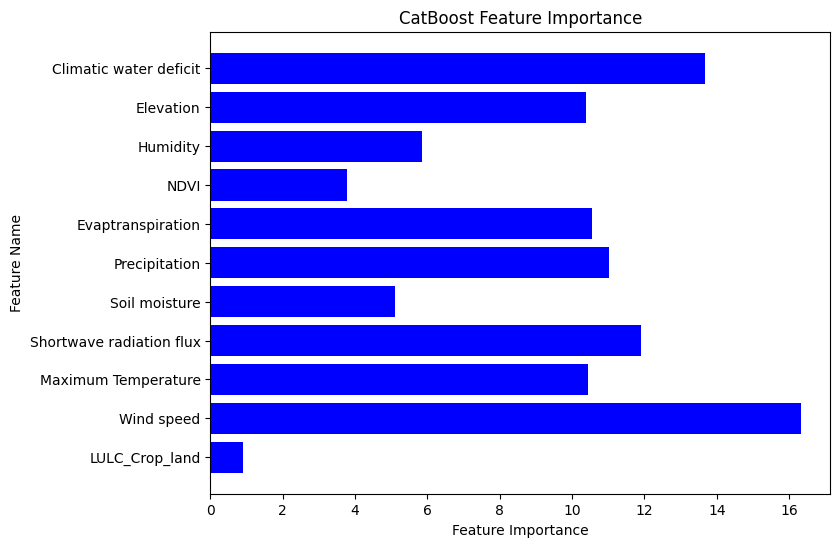

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from catboost import Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ✅ Load the trained CatBoost model
final_model = joblib.load("final_catboost_model.pkl")

# ✅ Extract test features and labels
X_test = X_test_final_with_indices
y_test = y_test

# ✅ Make predictions on the test set
print("\n📊 Evaluating Final CatBoost Model on Test Data...")
y_pred_test = final_model.predict(X_test)

# ✅ Compute test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# ✅ Display final test performance
print("\n🎯 Final CatBoost Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test R² Score: {r2_test:.4f}")

# ✅ Save test results
test_results = {
    "Test MSE": mse_test,
    "Test MAE": mae_test,
    "Test R²": r2_test
}
df_test_results = pd.DataFrame([test_results])
df_test_results.to_csv("catboost_test_results.csv", index=False)
print("\n✅ Test results saved successfully!")

# ✅ Plot Feature Importance
feature_importances = final_model.get_feature_importance()
feature_names = X_test.columns

plt.figure(figsize=(8, 6))
plt.barh(feature_names, feature_importances, color='blue')
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("CatBoost Feature Importance")
plt.gca().invert_yaxis()  # Reverse order for better visualization
plt.show()
